# Prioritizing Content Refresh Opportunities with Machine Learning: A Client-Grouped Evaluation

## Abstract

This study asks whether machine learning can help prioritize content pages for review based on signals associated with declining search performance. Using 30,000 anonymized content records, I trained a Random Forest classifier and evaluated it using a client-grouped split that kept clients separate between training and held-out test data. On the held-out set, the Random Forest achieved an F1 score of **0.831**, compared with **0.052** for a transparent freshness-and-visibility baseline using the same evaluation set. The model was then used to rank pages into a human-review queue, with recent impression and visibility signals among the strongest predictive features and the top 50 pages organized into observable diagnostic pathways. These results support using the model as **decision-support for prioritizing content review**, but they do not establish that content refreshes cause improved search performance or guarantee performance on future data.

---


In [115]:
!git clone https://github.com/yara-08/ML-FlyRank-Internship2.git

Cloning into 'ML-FlyRank-Internship2'...
remote: Enumerating objects: 206, done.
remote: Counting objects: 100% (206/206), done.
remote: Compressing objects: 100% (158/158), done.
remote: Total 206 (delta 93), reused 111 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (206/206), 2.54 MiB | 10.28 MiB/s, done.
Resolving deltas: 100% (93/93), done.


# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/yara-08/ML-FlyRank-Internship2/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*


### Research question

Can a machine-learning model help prioritize content pages for human review based on signals associated with declining search performance?

### Decision supported

The intended decision is **which pages should receive attention first for further content-performance investigation**.

The model is designed as decision support rather than an automatic refresh decision. A high model score indicates that a page resembles patterns associated with the declining class in the evaluated data; it does not establish that the page is incorrect, that it should definitely be refreshed, or that a refresh would improve future performance.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



### Dataset

This study uses the anonymized content-refresh dataset, `content_refresh_anonymized.csv`. The dataset contains **30,000 content records and 44 columns**. Each record represents an anonymized content page with search-performance, engagement, content, and freshness-related signals.

The dataset includes variables such as search volume, impressions, clicks, sessions, engaged sessions, click-through rate, average search position, days since last update, and trend information.

### Target and modeling population

The target was defined from `trend_direction`, with `down` treated as the declining class and the remaining observations treated as the non-declining class.

The target distribution was:

- **16,262 declining pages (54.2%)**
- **13,738 non-declining pages (45.8%)**

The full 30,000-row dataset was used for model development and evaluation. The data were divided using a **client-grouped split**. The training set contained **23,837 rows from 25 clients**, while the held-out test set contained **6,163 rows from 7 clients**. No client appeared in both sets.

### Variables

The model used numerical search-performance, engagement, content, and freshness features. Examples include:

- search and visibility measures such as impressions, clicks, search volume, and average position
- engagement measures such as sessions, engaged sessions, and click-through rate
- freshness and content measures such as days since last update, word count, and character count

Missing numerical values were imputed using medians calculated from the training data, and missingness indicators were added for variables with missing values.

### Exclusions

Variables that could directly reveal the target or create identifier-based shortcuts were excluded from the model. These included:

- `trend_direction`
- `trend_pct`
- `target`
- `content_id`
- `client_id`
- `baseline_score`
- `baseline_prediction`

Target-related variables were excluded because using them as predictive features could leak outcome information into the model. Client and content identifiers were excluded to prevent the model from learning entity-specific shortcuts.

The dataset is anonymized, and the research artifact contains no client names, private URLs, private search queries, or other identifying information.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



### 3.1 Assumptions

The analysis treats the available page-level signals as observations that can be used to identify patterns associated with declining search performance. The model is intended to support prioritization for human review rather than make an automatic decision to refresh a page.

The analysis is observational. A predicted declining outcome does not establish that a page is incorrect, that it should be refreshed, or that refreshing it would improve future search performance.

Because the modeling dataset does not provide sufficient information to establish the exact timing of every derived trend variable, the analysis does not claim to be a fully time-aware causal evaluation.

### 3.2 Label definition

The classification target was derived from `trend_direction`.

- `down` → **1 (declining)**
- all other observed trend categories → **0 (non-declining)**

The resulting dataset contained **16,262 declining pages (54.2%)** and **13,738 non-declining pages (45.8%)**.

The target was used only as the outcome variable and was excluded from the model's predictive features.

### 3.3 Features and preprocessing

The model used numerical features representing search visibility, search performance, engagement, content characteristics, and freshness.

Examples include:

- `search_volume`
- `impressions_90d`
- `clicks_90d`
- `sessions_90d`
- `engaged_sessions_90d`
- `days_since_last_update`
- `ctr`
- `avg_position`
- content-length variables such as `char_count` and `word_count`

Variables that could directly expose the target or act as identifiers were excluded before training.

The dataset contained missing values in several numerical variables, including `char_count`, `word_count`, competition/search-volume/CPC variables, and `scroll_rate`. Missing numerical values were imputed using medians calculated from the training data, and missingness indicators were added. After preprocessing, no missing values remained in either the training or test matrices.

### 3.4 Baseline

A transparent rule-based baseline was used to provide a simple reference point for the machine-learning model.

The baseline assigns points to two signals:

- **Freshness:** 0–3 points based on freshness tier
- **Search visibility:** 0–3 points based on impression tier

The two scores are added to produce a baseline score from 0 to 6. Pages with a score of **4 or higher** receive the reason code `STALE_VISIBLE` and the action label `REFRESH_CONTENT`.

The ranked baseline queue is sorted by baseline score, with `impressions_90d` used as a tie-breaker.

This baseline was intentionally designed to be simple and interpretable. It provides a transparent reference for assessing whether the machine-learning approach captures additional predictive information beyond freshness and visibility alone.

### 3.5 Model and validation design

The selected model was a **Random Forest Classifier** with **200 trees** and `random_state=42`.

The primary evaluation used a **client-grouped train/test split** so that the same client could not appear in both training and held-out test data. The training set contained **23,837 rows from 25 clients**, while the test set contained **6,163 rows from 7 clients**, with **zero shared clients** between the two sets.

The model was trained only on the training portion. The held-out test set was used for final evaluation.

The primary metrics were accuracy, precision, recall, and F1 score. F1 was emphasized because it summarizes precision and recall for the binary classification task.

As a validation-sensitivity check, a separate random split was also evaluated. The random split produced a higher F1 score (**0.877**) than the client-grouped split (**0.831**) and contained clients shared between training and test data. The grouped result is therefore treated as the primary and more conservative evaluation.

### 3.6 Leakage checks

The modeling workflow explicitly excluded variables that could leak target information or allow the model to learn identifiers. These included:

- `trend_direction`
- `trend_pct`
- `target`
- `content_id`
- `client_id`
- `baseline_score`
- `baseline_prediction`

The leakage audit found no use of these variables as predictive features.

The baseline also used only observable page-level signals and did not use future-window variables, labels, or product-generated flags.

A full temporal-leakage determination was not possible because the available starter dataset does not provide enough information to establish the exact timing of the calculation of every derived trend variable. This limitation is retained in the interpretation of the results.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

The Random Forest was evaluated against the rule-based baseline on the same held-out client-grouped test set. The results below report predictive performance, classification errors, feature contribution, and the composition of the model-ranked review queue.

All results are evaluated on held-out data and are presented as evidence of predictive performance within this dataset and validation design. They should not be interpreted as evidence of causation or as proof that model-guided content interventions will improve future search performance.

### 4.1 Model performance versus baseline

The Random Forest was evaluated against the rule-based baseline on the same held-out client-grouped test set of **6,163 pages from 7 clients**. Because no client appeared in both the training and test sets, the evaluation reduces the risk of the model benefiting from client-specific overlap.

| Method | Accuracy | Precision | Recall | F1 |
|---|---:|---:|---:|---:|
| Rule-based baseline | 0.482 | 0.399 | 0.028 | 0.052 |
| Random Forest | **0.826** | **0.824** | **0.838** | **0.831** |

The Random Forest achieved higher accuracy, precision, recall, and F1 than the rule-based baseline on the same held-out data. The largest improvement was in recall: the baseline identified only a small proportion of declining pages, whereas the Random Forest identified substantially more of them while also achieving higher precision.

The F1 score increased from **0.052** for the baseline to **0.831** for the Random Forest, an absolute improvement of **0.779**. This indicates substantially stronger predictive performance on the held-out test set under the grouped validation design.

These results demonstrate improved **prediction of the dataset's declining label**. They do not establish that the model can cause future search performance to improve, explain why a page declined, or determine that a particular content intervention is appropriate.

**Figure 1. Model performance versus the rule-based baseline.** The Random Forest outperformed the baseline across accuracy, precision, recall, and F1 on the same held-out client-grouped test set.

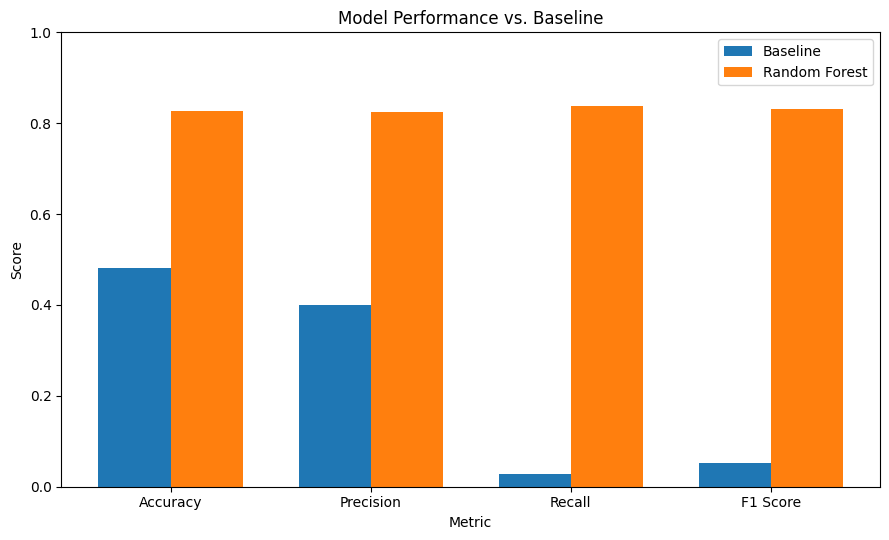

Figure saved to: work/figures/model_vs_baseline_metrics.png


In [116]:
# Figure 1 — Model performance versus baseline

import matplotlib.pyplot as plt
import numpy as np
import os

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

baseline_values = [
    0.482,
    0.399,
    0.028,
    0.052
]

random_forest_values = [
    0.826,
    0.824,
    0.838,
    0.831
]

x = np.arange(len(metrics))
width = 0.36

fig, ax = plt.subplots(figsize=(9, 5.5))

ax.bar(
    x - width / 2,
    baseline_values,
    width,
    label="Baseline"
)

ax.bar(
    x + width / 2,
    random_forest_values,
    width,
    label="Random Forest"
)

ax.set_ylabel("Score")
ax.set_xlabel("Metric")
ax.set_title("Model Performance vs. Baseline")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)

ax.legend()

plt.tight_layout()

figure_path = "work/figures/model_vs_baseline_metrics.png"
os.makedirs(os.path.dirname(figure_path), exist_ok=True)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_path}")

### 4.2 Error analysis

The Random Forest correctly classified **5,089 of 6,163** held-out pages and misclassified **1,074 pages**.

The confusion matrix was:

| | Predicted non-declining | Predicted declining |
|---|---:|---:|
| **Actual non-declining** | 2,451 | 563 |
| **Actual declining** | 511 | 2,638 |

The model produced **563 false positives** and **511 false negatives**. The false positives are non-declining pages that were predicted as declining, while the false negatives are declining pages that the model failed to identify.

The errors show that the model did not perfectly separate the declining and non-declining classes. This supports treating model predictions as prioritization signals for human review rather than as automatic refresh decisions.

**Figure 2.** Confusion matrix for the validated Random Forest. The model correctly classified 5,089 of 6,163 held-out pages, with 563 false positives and 511 false negatives.

In [117]:
# ============================================================
# RESTORE ML-08 MODEL STATE FOR RESULTS FIGURES
# Uses the ACTUAL ML-08 pipeline — no mock data
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

# ------------------------------------------------------------
# 1. Load the original ML-08 dataset
# ------------------------------------------------------------

df = pd.read_csv(
    "/content/ML-FlyRank-Internship2/data/raw/content_refresh_anonymized.csv"
)

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]}")


# ------------------------------------------------------------
# 2. Create the target exactly as in ML-08
# ------------------------------------------------------------

df["target"] = (
    df["trend_direction"] == "down"
).astype(int)


# ------------------------------------------------------------
# 3. Recreate the SAME grouped split
# ------------------------------------------------------------

groups = df["client_id"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(df, groups=groups)
)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows: {len(test_df):,}")
print(f"Training clients: {train_df['client_id'].nunique()}")
print(f"Testing clients: {test_df['client_id'].nunique()}")


# ------------------------------------------------------------
# 4. Recreate the ML-08 baseline
# ------------------------------------------------------------

freshness_points = {
    "0-30": 0,
    "31-90": 1,
    "91-180": 2,
    "181+": 3,
}

visibility_points = {
    "low": 0,
    "moderate": 1,
    "good": 2,
    "excellent": 3,
}

df["baseline_score"] = (
    df["freshness_tier"].map(freshness_points)
    + df["impression_tier"].map(visibility_points)
)

df["baseline_prediction"] = (
    df["baseline_score"] >= 4
).astype(int)

train_df = df.iloc[train_idx].copy()
test_df = df.iloc[test_idx].copy()


# ------------------------------------------------------------
# 5. Create the ACTUAL ML-08 feature matrices
# ------------------------------------------------------------

drop_columns = [
    "content_id",
    "client_id",
    "trend_direction",
    "trend_pct",
    "target",
    "baseline_score",
    "baseline_prediction",
]

X_train = train_df.drop(columns=drop_columns)
X_test = test_df.drop(columns=drop_columns)

y_train = train_df["target"]
y_test = test_df["target"]


# ------------------------------------------------------------
# 6. One-hot encode exactly as ML-08
# ------------------------------------------------------------

X_train = pd.get_dummies(
    X_train,
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    drop_first=True
)

X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)


# ------------------------------------------------------------
# 7. Handle missing values exactly as ML-08
# ------------------------------------------------------------

missing_cols = [
    "char_count",
    "word_count",
    "competition",
    "search_volume",
    "cpc",
    "scroll_rate",
]

for col in missing_cols:

    X_train[f"{col}_missing"] = (
        X_train[col].isna().astype(int)
    )

    X_test[f"{col}_missing"] = (
        X_test[col].isna().astype(int)
    )

    median = X_train[col].median()

    X_train[col] = X_train[col].fillna(median)
    X_test[col] = X_test[col].fillna(median)


print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

print(
    "Remaining missing values (train):",
    X_train.isna().sum().sum()
)

print(
    "Remaining missing values (test):",
    X_test.isna().sum().sum()
)


# ------------------------------------------------------------
# 8. Train the ACTUAL ML-08 Random Forest
# ------------------------------------------------------------

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
)

rf.fit(
    X_train,
    y_train
)


# ------------------------------------------------------------
# 9. Generate ACTUAL held-out predictions
# ------------------------------------------------------------

rf_predictions = rf.predict(X_test)


# ------------------------------------------------------------
# 10. Generate ACTUAL permutation importance
# ------------------------------------------------------------

perm = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

perm_importance = (
    pd.DataFrame(
        {
            "Feature": X_test.columns,
            "Importance": perm.importances_mean,
        }
    )
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 11. Print validation checks
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("ML-08 MODEL STATE RESTORED")
print("=" * 60)

print("\nRandom Forest metrics:")

print(
    f"Accuracy : {accuracy_score(y_test, rf_predictions):.3f}"
)

print(
    f"Precision: {precision_score(y_test, rf_predictions):.3f}"
)

print(
    f"Recall   : {recall_score(y_test, rf_predictions):.3f}"
)

print(
    f"F1       : {f1_score(y_test, rf_predictions):.3f}"
)


print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test,
        rf_predictions
    )
)


print("\nTop 10 permutation importances:")
display(
    perm_importance.head(10)
)

Rows: 30,000
Columns: 44
Training rows: 23,837
Testing rows: 6,163
Training clients: 25
Testing clients: 7
X_train shape: (23837, 66)
X_test shape: (6163, 66)
Remaining missing values (train): 0
Remaining missing values (test): 0

ML-08 MODEL STATE RESTORED

Random Forest metrics:
Accuracy : 0.826
Precision: 0.824
Recall   : 0.838
F1       : 0.831

Confusion matrix:
[[2451  563]
 [ 511 2638]]

Top 10 permutation importances:


,Feature,Importance
0,impressions_last_30d,0.276184
1,impressions_prev_30d,0.265571
2,impressions_90d,0.018879
3,clicks_last_30d,0.009360
4,days_with_impressions,0.008343
5,impression_tier_low,0.005764
6,sessions_last_30d,0.005591
7,impression_tier_moderate,0.003610
8,ctr,0.002636
9,clicks_90d,0.001672


Confusion Matrix
[[2451  563]
 [ 511 2638]]


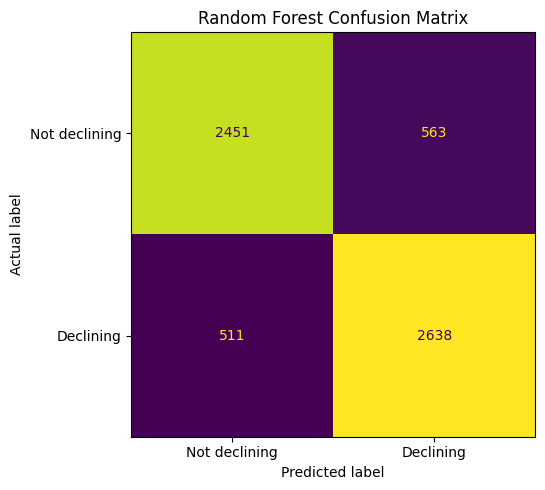


True Negatives : 2451
False Positives: 563
False Negatives: 511
True Positives : 2638

Total held-out pages: 6,163
Correctly classified pages: 5,089
Misclassified pages: 1,074

Figure saved to: work/figures/random_forest_confusion_matrix.png


In [118]:
# Figure 2 — Confusion matrix for the validated Random Forest

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import os

# Use the ACTUAL predictions generated by ML-08
cm = confusion_matrix(
    y_test,
    rf_predictions
)

print("Confusion Matrix")
print(cm)

# Create figure
fig, ax = plt.subplots(figsize=(6, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not declining", "Declining"]
)

disp.plot(
    ax=ax,
    values_format="d",
    colorbar=False
)

ax.set_title("Random Forest Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

plt.tight_layout()

# Save figure
figure_path = "work/figures/random_forest_confusion_matrix.png"
os.makedirs(os.path.dirname(figure_path), exist_ok=True)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Verification
tn, fp, fn, tp = cm.ravel()

print(f"\nTrue Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

print(f"\nTotal held-out pages: {cm.sum():,}")
print(f"Correctly classified pages: {cm.trace():,}")
print(f"Misclassified pages: {fp + fn:,}")

print(f"\nFigure saved to: {figure_path}")

### 4.3 Feature contribution

Permutation importance was used to examine the contribution of individual features to the Random Forest's predictive performance on the held-out test set. For each feature, its values were randomly permuted and the resulting change in F1 score was measured. Larger positive values indicate a larger reduction in predictive performance when that feature's information is disrupted.

The strongest contributors were:

| Feature                 | Permutation importance |
| ----------------------- | ---------------------: |
| `impressions_last_30d`  |               0.276184 |
| `impressions_prev_30d`  |               0.265571 |
| `impressions_90d`       |               0.018879 |
| `clicks_last_30d`       |               0.009360 |
| `days_with_impressions` |               0.008343 |


Recent impression measures were substantially more important than most other individual features in the permutation-importance analysis. In particular, `impressions_last_30d` and `impressions_prev_30d` had much larger permutation-importance values than the remaining features.

These results indicate that recent search-visibility measures contained strong predictive information for distinguishing declining and non-declining pages in this dataset. Feature importance should not be interpreted as evidence that these variables cause decline; it describes the model's predictive behavior within this dataset and evaluation setting.

**Figure 3.** Top-10 features by permutation importance on the held-out test set. Importance values represent the mean change in F1 score across 10 permutations.



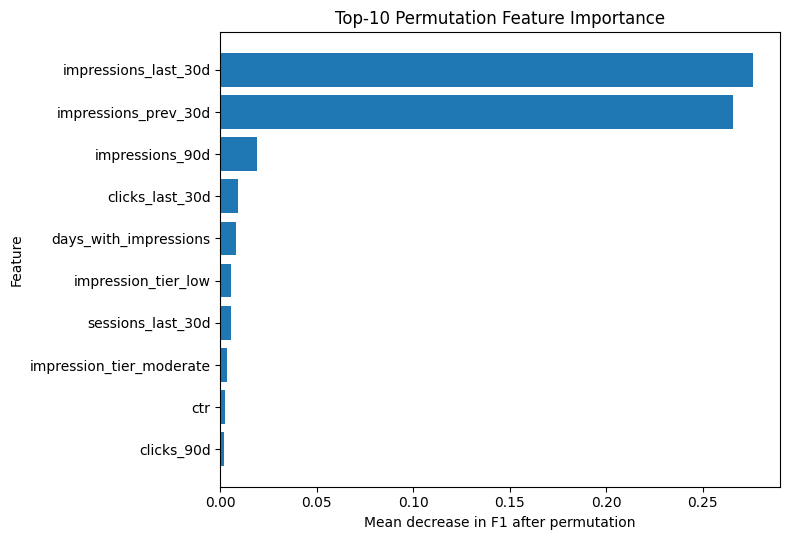

Top 10 permutation importances:


,Feature,Importance
0,impressions_last_30d,0.276184
1,impressions_prev_30d,0.265571
2,impressions_90d,0.018879
3,clicks_last_30d,0.009360
4,days_with_impressions,0.008343
5,impression_tier_low,0.005764
6,sessions_last_30d,0.005591
7,impression_tier_moderate,0.003610
8,ctr,0.002636
9,clicks_90d,0.001672



Figure saved to: work/figures/random_forest_top10_feature_importance.png


In [119]:
# ============================================================
# Figure 3 — Top-10 Permutation Feature Importance
# ============================================================

import matplotlib.pyplot as plt
import os

top10_features = (
    perm_importance
    .head(10)
    .sort_values(
        "Importance",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(8, 5.5)
)

ax.barh(
    top10_features["Feature"],
    top10_features["Importance"]
)

ax.set_xlabel(
    "Mean decrease in F1 after permutation"
)

ax.set_ylabel(
    "Feature"
)

ax.set_title(
    "Top-10 Permutation Feature Importance"
)

plt.tight_layout()

figure_path = (
    "work/figures/"
    "random_forest_top10_feature_importance.png"
)

os.makedirs(
    os.path.dirname(figure_path),
    exist_ok=True
)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Top 10 permutation importances:")
display(
    perm_importance
    .head(10)
)

print(
    f"\nFigure saved to: {figure_path}"
)

###4.4 Held-out queue composition

The validated Random Forest was used to rank the **6,163 pages in the grouped held-out test set** by their score for the declining class. This ranking was then combined with observable performance signals to assign each page a primary review archetype. These archetypes are **workflow categories rather than causal diagnoses**: they describe which signals a reviewer should investigate next, without claiming to explain why a page declined.

The largest archetype was `MODEL_PRIORITY_NO_SIMPLE_SIGNAL`, representing **2,639 pages (42.8%)**. These pages received a relatively high model ranking but did not match one of the predefined observable signal patterns. Keeping this category prevents the playbook from inventing an explanation when the available signals do not support one.

The remaining pages were assigned to more specific observable patterns:

* `DECLINING_WITHOUT_CLICKS`: 1,607 pages (26.1%)
* `LOW_VISIBILITY`: 797 pages (12.9%)
* `VISIBILITY_DECLINE`: 702 pages (11.4%)
* `RECENT_VISIBILITY_LOSS`: 418 pages (6.8%)

The resulting distribution shows that the model-ranked queue contains a mixture of specific performance patterns and cases requiring broader manual investigation. The archetype distribution therefore provides **context for the review workload**, rather than evidence that any particular pattern causes declining performance.

For practical use, the workflow surfaces the **top 50 pages** as an initial human-review queue. Within this top-50 queue, **39 pages (78%)** were classified as `DECLINING_WITHOUT_CLICKS`, **10 pages (20%)** as `RECENT_VISIBILITY_LOSS`, and **1 page (2%)** as `VISIBILITY_DECLINE`. These categories determine the recommended review pathway but do not automatically determine the intervention.

**Figure 4.** Distribution of review archetypes across the complete held-out queue of 6,163 pages. The figure shows the relative size of the predefined workflow categories and the large `MODEL_PRIORITY_NO_SIMPLE_SIGNAL` category.

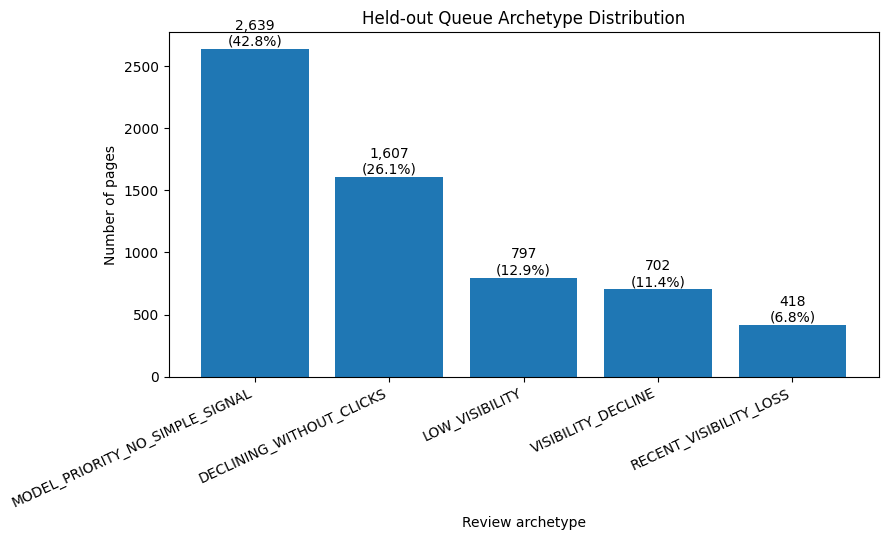

Total pages represented: 6,163
Figure saved to: work/figures/held_out_archetype_distribution.png


In [120]:
# Figure 4 — Held-out queue archetype distribution

import matplotlib.pyplot as plt
import os

archetypes = [
    "MODEL_PRIORITY_NO_SIMPLE_SIGNAL",
    "DECLINING_WITHOUT_CLICKS",
    "LOW_VISIBILITY",
    "VISIBILITY_DECLINE",
    "RECENT_VISIBILITY_LOSS"
]

counts = [
    2639,
    1607,
    797,
    702,
    418
]

total = sum(counts)

percentages = [
    count / total * 100
    for count in counts
]

# Create figure
fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.bar(
    archetypes,
    counts
)

ax.set_ylabel("Number of pages")
ax.set_xlabel("Review archetype")
ax.set_title("Held-out Queue Archetype Distribution")

# Rotate long category labels
plt.xticks(
    rotation=25,
    ha="right"
)

# Add percentage labels above bars
for bar, count, percentage in zip(bars, counts, percentages):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

# Save paper-ready figure
figure_path = "work/figures/held_out_archetype_distribution.png"
os.makedirs(os.path.dirname(figure_path), exist_ok=True)

plt.savefig(
    figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Total pages represented: {total:,}")
print(f"Figure saved to: {figure_path}")

## 5. Limitations

*What this work cannot claim.*

This work is a **decision-support prototype for prioritizing content reviews**, not a causal or autonomous content-optimization system. Several limitations define what can and cannot be concluded from the results.

First, the Random Forest predicts the dataset's **declining label**; it does not establish why a page declined or whether a particular intervention will improve its performance. The archetypes and reason codes are based on observable performance patterns and should therefore be interpreted as **review signals rather than causal diagnoses**.

Second, the model was validated using a **grouped client split**, with 25 clients in training and 7 completely unseen clients in the held-out test set. This supports evaluation of generalization across clients, but it does **not establish performance on future time periods, future data distributions, or other populations**.

Third, the held-out ranking contains **6,163 pages**, but the practical workflow surfaces only the top 50 pages for initial human review. The concentration of particular archetypes in this queue is an observed property of this held-out ranking; it does not demonstrate that these patterns cause decline or that reviewing these pages will produce better outcomes.

Fourth, the **decline score is a ranking signal**, not a calibrated probability. A higher score means that the model ranked a page more highly for review under this dataset and validation setup. It should not be interpreted as a guarantee that a page will decline or as a measure of the expected benefit of intervention.

Fifth, the current monitoring results cannot establish **future drift or predictive-performance degradation**. The held-out ranking data used for the playbook does not contain the target column, so an observed decline-rate change cannot currently be assessed from this queue. Future labeled outcomes would be required to monitor predictive performance over time and assess whether model retraining is warranted.

Finally, the system does not incorporate all information that may be relevant to a real content decision, such as the full content context, search intent, technical circumstances, business importance, seasonality, or measurement issues. Consequently, the output should **not be used to automatically publish, refresh, rewrite, remove, redirect, or otherwise substantially modify content**. Human review remains necessary before any intervention.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

The results support a **prioritized approach to content review**, with attention focused first on pages receiving the highest model scores for the declining class. Because the model identifies patterns associated with decline rather than causes of decline, the recommendations below describe **investigative priorities rather than automatic interventions**.

 1. **Prioritize the highest-ranked pages for review.**

 Rather than treating all pages equally, reviewers should initially focus on the pages receiving the highest model scores. In the held-out set of 6,163 pages, the highest-ranked page received a score of 0.940, while the mean score among the top 20 pages was 0.919. These scores provide a practical way to concentrate limited review capacity on pages the model considers most relevant to the declining class.

 2. **Investigate substantial impression declines accompanied by zero recent clicks.**

 This was the dominant pattern among the highest-ranked pages: **39 of the top 50 pages (78%)** experienced a substantial recent impression decline while still receiving impressions but no clicks. These pages should receive particular attention to search-result visibility, click-through behavior, and the relationship between the page and its target search intent. The observed pattern should not, however, be interpreted as evidence that poor click-through performance caused the decline.

 3. **Investigate pages that have lost all recent search visibility.**

 **10 of the top 50 pages (20%)** had impressions in the previous 30-day period but none in the latest 30 days. For these pages, the first priority should be determining whether the loss represents a genuine visibility change or a measurement, indexing, technical, or other underlying issue before considering a content intervention.

 4. **Review broader performance declines when no more specific pattern is present.**

 A smaller portion of the highest-ranked pages showed substantial impression declines without the more specific patterns above. These cases should undergo broader performance investigation, including examination of recent visibility and other available contextual signals, before deciding whether any content change is justified.

5. **Do not force an explanation when the available evidence is insufficient.**

 Across the full held-out set, **42.8% of pages** were highly ranked by the model without matching one of the simple observable patterns used for review classification. These cases should remain subject to manual investigation rather than being assigned an unsupported explanation. This is an important safeguard against turning a predictive ranking into an unjustified causal diagnosis.

 **Overall recommendation.**

The findings support using machine-learning predictions to **allocate review attention**, particularly toward pages showing strong model scores and substantial recent visibility changes. However, the evidence does not support automatically refreshing, rewriting, removing, or otherwise modifying content on the basis of model predictions alone. Any intervention should follow verification of the underlying performance change and consideration of page-specific context by a human reviewer.


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*



The deployed paper uses the following figures and tables from the validated analysis. The figures are generated from the held-out evaluation results and saved under work/figures/ for use by the research page.

### Figures

| Artifact | Purpose |
|---|---|
| `model_vs_baseline_metrics.png` | Comparison of Random Forest and rule-based baseline across accuracy, precision, recall, and F1 |
| `random_forest_confusion_matrix.png` | Classification errors on the held-out test set |
| `random_forest_top10_feature_importance.png` | Top features by permutation importance |
| `held_out_archetype_distribution.png` | Distribution of review archetypes across the held-out queue |

### Tables

The paper embeds the following result tables:

- Model performance versus baseline
- Random Forest confusion matrix
- Top permutation-importance features
- Held-out queue archetype counts and percentages

All artifacts are derived from the same held-out evaluation described in the Results section.

In [121]:
from pathlib import Path

figure_dir = Path("work/figures")

required_figures = [
    "model_vs_baseline_metrics.png",
    "random_forest_confusion_matrix.png",
    "random_forest_top10_feature_importance.png",
    "held_out_archetype_distribution.png",
]

print("Paper artifacts:")

for filename in required_figures:
    path = figure_dir / filename
    print(f"{'✓' if path.exists() else '✗'} {path}")

Paper artifacts:
✓ work/figures/model_vs_baseline_metrics.png
✓ work/figures/random_forest_confusion_matrix.png
✓ work/figures/random_forest_top10_feature_importance.png
✓ work/figures/held_out_archetype_distribution.png


## 8. Reproducibility


The analysis is designed to be inspectable and reproducible from the project repository. The notebooks, scripts, generated figures, and supporting outputs are organized within the repository so that the analysis can be reviewed and rerun.

The main analysis is documented in the capstone notebook:

- `notebooks/capstone.ipynb` — end-to-end capstone analysis, including the baseline, Random Forest model, grouped validation, leakage checks, results, limitations, recommendations, and paper artifacts.

Supporting project materials and reusable analysis code are maintained in the repository under `scripts/`, `work/`, and `outputs/`. The paper figures used in this report are stored under `work/figures/`.

The final project repository is:

**[ML-FlyRank-Internship2](https://github.com/yara-08/ML-FlyRank-Internship2)**

The analysis uses the validation design and assumptions described in the Methodology section. Results reported in this paper should therefore be interpreted in the context of that specific dataset, feature set, model configuration, and held-out client-grouped evaluation.

## 9. Acknowledgments & data credit

This work was completed as part of the FlyRank Machine Learning Internship.

The analysis was built on the **FlyRank ML Internship dataset**, provided for the internship's machine-learning track. The dataset and project materials were used in accordance with the applicable data-use requirements.

**Data source:** [FlyRank AI](https://flyrank.ai)

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
